# Notebook 04 — Làm sạch dữ liệu (Data Cleaning)

**DS108 — Tiền Xử Lý Dữ Liệu**  
**Nhóm:** La Gia Hân (24520448) · Huỳnh Gia Hào (24520457)

---

## Mục tiêu
Làm sạch **từng nguồn dữ liệu độc lập** trước khi tích hợp ở notebook 05.

| Input | Output |
|---|---|
| `data/processed/nsmo_raw_merged.csv` | `data/processed/nsmo_v1_clean.csv` |
| `data/processed/hanoi_raw_merged.csv` | `data/processed/hanoi_v1_clean.csv` |
| `data/processed/danang_raw_merged.csv` | `data/processed/danang_v1_clean.csv` |
| `data/processed/hcm_raw_merged.csv` | `data/processed/hcm_v1_clean.csv` |

## Quyết định kỹ thuật

| Vấn đề | NSMO | Weather |
|---|---|---|
| Missing Load | **Median** — phân phối có tính mùa vụ, lệch; median ít bị kéo bởi outlier hơn mean | — |
| Missing Price | **Forward fill** — giá biên bám sát chu kỳ liền trước do cơ chế khớp lệnh thị trường | — |
| Missing numeric | — | **Linear interpolation** — nhiệt độ/độ ẩm thay đổi liên tục, tuyến tính là xấp xỉ hợp lý |
| Missing categorical | — | **Forward fill** — không thể nội suy giữa 2 trạng thái rời rạc (vd: `partly-cloudy` → `?` → `clear`) |
| Outlier | **IQR detect → ghi log, KHÔNG xóa** — giá trị cực đoan có thể là thật (nắng nóng, sự cố hệ thống) | Tương tự |
| Duplicate | Drop | Drop |
| Datetime | Chuẩn hóa UTC+7, bỏ timezone-aware | Chuẩn hóa UTC+7 |

In [19]:
# CONFIG CELL — imports, REPO_ROOT, paths, style
import json
import os
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# REPO_ROOT: notebook có thể chạy từ notebooks/ hoặc từ root repo
# Logic kiểm tra tên thư mục hiện tại để đảm bảo paths tương đối luôn đúng
REPO_ROOT = Path(os.getcwd())
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)

# Paths
PROCESSED_DIR = Path('data/processed')
LOG_DIR = Path('reports/cleaning_logs')
REPORTS_EDA = Path('reports/eda_before')

LOG_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_EDA.mkdir(parents=True, exist_ok=True)
assert PROCESSED_DIR.exists(), (
    '[ERROR] data/processed/ not found. Chay NB01-NB03 truoc.'
)

# Matplotlib / Seaborn style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 4)})

print(f'[OK] Working directory  : {os.getcwd()}')
print(f'[OK] PROCESSED_DIR      : {PROCESSED_DIR.resolve()}')
print(f'[OK] LOG_DIR            : {LOG_DIR.resolve()}')


[OK] Working directory  : c:\Users\ASUS\DS108-Project
[OK] PROCESSED_DIR      : C:\Users\ASUS\DS108-Project\data\processed
[OK] LOG_DIR            : C:\Users\ASUS\DS108-Project\reports\cleaning_logs


## 0. Cấu hình

Cell config bên dưới gộp toàn bộ imports, REPO_ROOT, paths và style vào một cell duy nhất theo chuẩn code quality.
Chạy cell này trước tất cả các cell còn lại.

## 1. Hàm tiện ích tái sử dụng

In [20]:
def load_processed(filename: str, ts_col: str = 'Timestamp') -> pd.DataFrame:
    """Doc file CSV tu data/processed/, parse datetime, bo timezone.

    Args:
        filename: Ten file CSV can doc (vi du: 'nsmo_raw_merged.csv').
        ts_col: Ten cot chua thoi gian. Mac dinh 'Timestamp'.

    Returns:
        DataFrame da sort theo thoi gian va reset index.
    """
    path = PROCESSED_DIR / filename
    assert path.exists(), f'[ERROR] File not found: {path}'
    df = pd.read_csv(path, encoding='utf-8-sig')
    assert ts_col in df.columns, (
        f"[ERROR] Cot '{ts_col}' khong ton tai trong {filename}.\n"
        f"Columns thuc te: {list(df.columns)}"
    )
    df[ts_col] = pd.to_datetime(df[ts_col])
    # Bo timezone ve naive datetime (UTC+7) de tranh loi khi merge
    if df[ts_col].dt.tz is not None:
        df[ts_col] = df[ts_col].dt.tz_localize(None)
    df = df.sort_values(ts_col).reset_index(drop=True)
    print(f'  [OK] Doc: {filename} -> {df.shape[0]:,} dong x {df.shape[1]} cot')
    return df


def report_missing(df: pd.DataFrame, label: str = '') -> pd.DataFrame:
    """In bang missing values; tra ve DataFrame chi gom cot co missing.

    Args:
        df: DataFrame can kiem tra.
        label: Nhan hien thi trong output.

    Returns:
        DataFrame chua thong ke missing, hoac DataFrame rong neu khong co missing.
    """
    n = len(df)
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if miss.empty:
        print(f'  [OK] [{label}] Khong co missing value')
        return pd.DataFrame()
    result = pd.DataFrame({
        'missing_count': miss,
        'missing_pct': (miss / n * 100).round(2)
    }).sort_values('missing_pct', ascending=False)
    print(f'  [WARNING] [{label}] Missing values:')
    print(result.to_string())
    return result


def detect_outliers_iqr(
    df: pd.DataFrame,
    cols: list,
    ts_col: str = 'Timestamp',
    label: str = '',
    multiplier: float = 1.5
) -> pd.DataFrame:
    """Phat hien outlier bang phuong phap Interquartile Range (IQR).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame can kiem tra.
    cols : list
        Danh sach cac cot numeric can detect outlier.
    ts_col : str, optional
        Cot moc thoi gian de luu vao log. Mac dinh 'Timestamp'.
    label : str, optional
        Nhan dung cho ten file log.
    multiplier : float, optional
        He so nhan cho IQR. Mac dinh 1.5 (tieu chuan Tukey).

    Returns
    -------
    pd.DataFrame
        Bang tom tat so luong outlier tren moi cot.

    Notes
    -----
    Outlier duoc ghi log ra file nhung KHONG xoa bao khoi dataset.
    Load = 0 co the xay ra khi cat tai; gia tri cao la dinh phu tai thuc.
    """
    all_outlier_rows = []
    summary_rows = []

    for col in cols:
        if col not in df.columns:
            continue
        series = df[col].dropna()
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lo = q1 - multiplier * iqr
        hi = q3 + multiplier * iqr

        mask = (df[col] < lo) | (df[col] > hi)
        n_out = mask.sum()

        summary_rows.append({
            'column': col, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
            'lower_fence': lo, 'upper_fence': hi,
            'n_outliers': n_out,
            'pct_outliers': round(n_out / len(df) * 100, 3)
        })

        if n_out > 0:
            rows = df.loc[mask, [ts_col, col]].copy()
            rows['column'] = col
            rows['lower_fence'] = lo
            rows['upper_fence'] = hi
            all_outlier_rows.append(rows)

    summary_df = pd.DataFrame(summary_rows)
    detail_df = pd.concat(all_outlier_rows) if all_outlier_rows else pd.DataFrame()

    print(f'  Outlier summary (IQR x {multiplier}) [{label}]:')
    print(
        summary_df[['column', 'lower_fence', 'upper_fence', 'n_outliers', 'pct_outliers']]
        .to_string(index=False)
    )

    ts_str = datetime.now().strftime('%Y%m%d_%H%M%S')
    log_path = LOG_DIR / f'outlier_{label}_{ts_str}.csv'
    if not detail_df.empty:
        detail_df.to_csv(log_path, index=False, encoding='utf-8-sig')
        print(f'  -> Da luu log outlier: {log_path}')
    else:
        print(f'  [OK] [{label}] Khong phat hien outlier ngoai fence')

    return summary_df


def drop_duplicate_timestamps(
    df: pd.DataFrame,
    ts_col: str = 'Timestamp',
    label: str = ''
) -> pd.DataFrame:
    """Xoa cac dong co timestamp trung lap, giu dong dau tien.

    Args:
        df: DataFrame dau vao.
        ts_col: Ten cot timestamp.
        label: Nhan hien thi trong output.

    Returns:
        DataFrame sau khi da xoa duplicate.
    """
    n_before = len(df)
    df = df.drop_duplicates(subset=[ts_col], keep='first').reset_index(drop=True)
    n_dropped = n_before - len(df)
    if n_dropped:
        print(f'  [WARNING] [{label}] Dropped {n_dropped} duplicate timestamp(s)')
    else:
        print(f'  [OK] [{label}] Khong co duplicate timestamp')
    return df


def save_clean(df: pd.DataFrame, filename: str) -> None:
    """Luu DataFrame ra data/processed/ voi encoding utf-8-sig.

    Args:
        df: DataFrame can luu.
        filename: Ten file CSV dau ra.
    """
    path = PROCESSED_DIR / filename
    df.to_csv(path, index=False, encoding='utf-8-sig')
    print(f'  -> Da luu: {filename} -> {df.shape[0]:,} dong x {df.shape[1]} cot')


print('[OK] Cac ham tien ich da san sang')


[OK] Cac ham tien ich da san sang


## 2. Làm sạch NSMO

### Bối cảnh
Từ kết quả notebook 03:
- `nsmo_raw_merged.csv`: **52,608 dòng × 9 cột**, 0 missing, 0 gaps, 0 duplicate  
- Outlier Load nhẹ ~0.5–1% (bao gồm Load = 0), Price không có outlier IQR

> Vì NSMO không có missing, phần fillna đóng vai trò phòng thủ — kích hoạt nếu batch mới có missing.

In [21]:
# 2.1 Doc du lieu NSMO
nsmo = load_processed('nsmo_raw_merged.csv', ts_col='Timestamp')
print(f'  Giai doan: {nsmo["Timestamp"].min()} -> {nsmo["Timestamp"].max()}')
print(f'  Dtypes:\n{nsmo.dtypes.to_string()}')


  [OK] Doc: nsmo_raw_merged.csv -> 52,608 dong x 9 cot
  Giai doan: 2023-03-11 00:30:00 -> 2026-03-11 00:00:00
  Dtypes:
Timestamp         datetime64[us]
Load_North               float64
Load_Central             float64
Load_South               float64
Load_National            float64
Price_North              float64
Price_Central            float64
Price_South              float64
Price_National           float64


In [22]:
# 2.2 Kiem tra missing
nsmo_missing = report_missing(nsmo, label='NSMO')


  [OK] [NSMO] Khong co missing value


In [23]:
# 2.3 Xu ly missing
NSMO_LOAD_COLS = ['Load_North', 'Load_Central', 'Load_South', 'Load_National']
NSMO_PRICE_COLS = ['Price_North', 'Price_Central', 'Price_South', 'Price_National']

nsmo_clean = nsmo.copy()

# Load: fillna bang median tung cot.
# Phan phoi Load co tinh mua vu (bimodal theo gio cao/thap diem).
# Median it bi keo boi spike hon mean, giu dac tinh phan phoi tot hon.
for col in NSMO_LOAD_COLS:
    n_miss = nsmo_clean[col].isna().sum()
    if n_miss > 0:
        med = nsmo_clean[col].median()
        nsmo_clean[col] = nsmo_clean[col].fillna(med)
        print(f'  Load fillna median ({med:,.1f} MW): {n_miss} dong -- {col}')
    else:
        print(f'  [OK] Khong missing: {col}')

# Price: forward fill.
# Gia bien trong thi truong dien canh tranh bam sat gia chu ky lien truoc
# (co che khop lenh VCGM). Forward fill mo phong dung hanh vi nay.
for col in NSMO_PRICE_COLS:
    n_miss = nsmo_clean[col].isna().sum()
    if n_miss > 0:
        nsmo_clean[col] = nsmo_clean[col].ffill()
        # Edge case: neu missing ngay dau file, bfill xu ly
        nsmo_clean[col] = nsmo_clean[col].bfill()
        print(f'  Price ffill: {n_miss} dong -- {col}')
    else:
        print(f'  [OK] Khong missing: {col}')

print(f'\n  Missing sau xu ly: {nsmo_clean.isnull().sum().sum()}')


  [OK] Khong missing: Load_North
  [OK] Khong missing: Load_Central
  [OK] Khong missing: Load_South
  [OK] Khong missing: Load_National
  [OK] Khong missing: Price_North
  [OK] Khong missing: Price_Central
  [OK] Khong missing: Price_South
  [OK] Khong missing: Price_National

  Missing sau xu ly: 0


In [24]:
# 2.4 Drop duplicate timestamp
nsmo_clean = drop_duplicate_timestamps(nsmo_clean, ts_col='Timestamp', label='NSMO')


  [OK] [NSMO] Khong co duplicate timestamp


In [25]:
# 2.5 Detect Outlier IQR
# Ghi nhan de co kiem soat; KHONG xoa — outlier co the la gia tri thuc.
outlier_cols_nsmo = NSMO_LOAD_COLS + NSMO_PRICE_COLS
nsmo_outlier_summary = detect_outliers_iqr(
    nsmo_clean, cols=outlier_cols_nsmo,
    ts_col='Timestamp', label='nsmo'
)

# Giai thich: Price lower_fence am, n_outliers = 0.
# Q1 = 0 o nhieu mien (thua cong suat tai tao) lam IQR rong, dan den fence am. Day la dac tinh phan phoi bimodal cua gia bien, khong phai loi IQR. Price khong can xu ly outlier.
print('  [INFO] Price lower_fence am: Q1 = 0 (thua cong suat tai tao)')
print('         -> IQR rong -> fence am -> khong co diem nao bi flag')
print('         -> Phan phoi bimodal cua gia bien, khong phai loi')


  Outlier summary (IQR x 1.5) [nsmo]:
        column  lower_fence  upper_fence  n_outliers  pct_outliers
    Load_North  8115.537500 24991.437500         531         1.009
  Load_Central  1630.292625  5308.847625         277         0.527
    Load_South  7780.000000 22920.000000         306         0.582
 Load_National 18694.812500 52056.912500         340         0.646
   Price_North -2205.889500  3676.482500           0         0.000
 Price_Central -1594.187625  2656.979375           0         0.000
   Price_South -1767.477750  2945.796250           0         0.000
Price_National -2265.000000  3775.000000           0         0.000
  -> Da luu log outlier: reports\cleaning_logs\outlier_nsmo_20260607_091955.csv
  [INFO] Price lower_fence am: Q1 = 0 (thua cong suat tai tao)
         -> IQR rong -> fence am -> khong co diem nao bi flag
         -> Phan phoi bimodal cua gia bien, khong phai loi


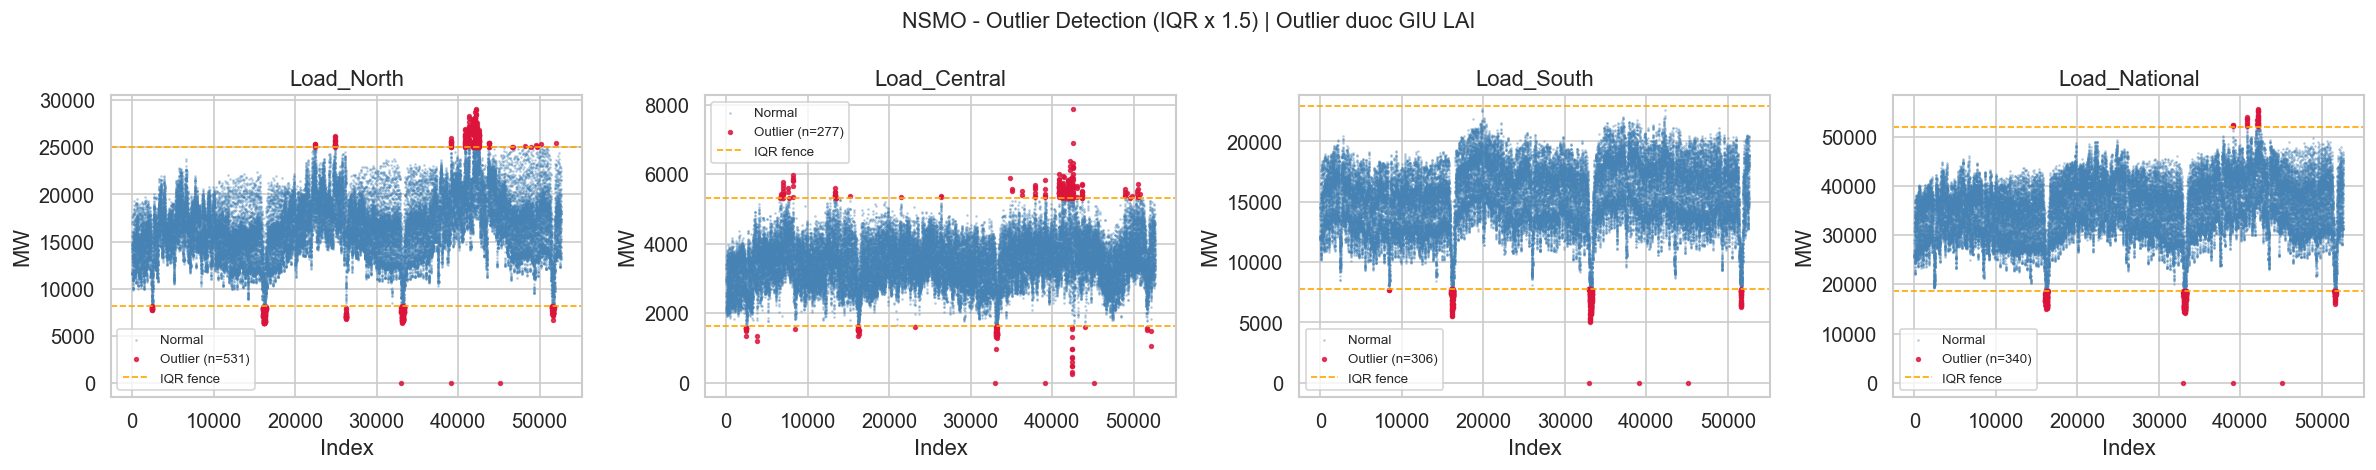

  -> Da luu: nsmo_outlier_load.png


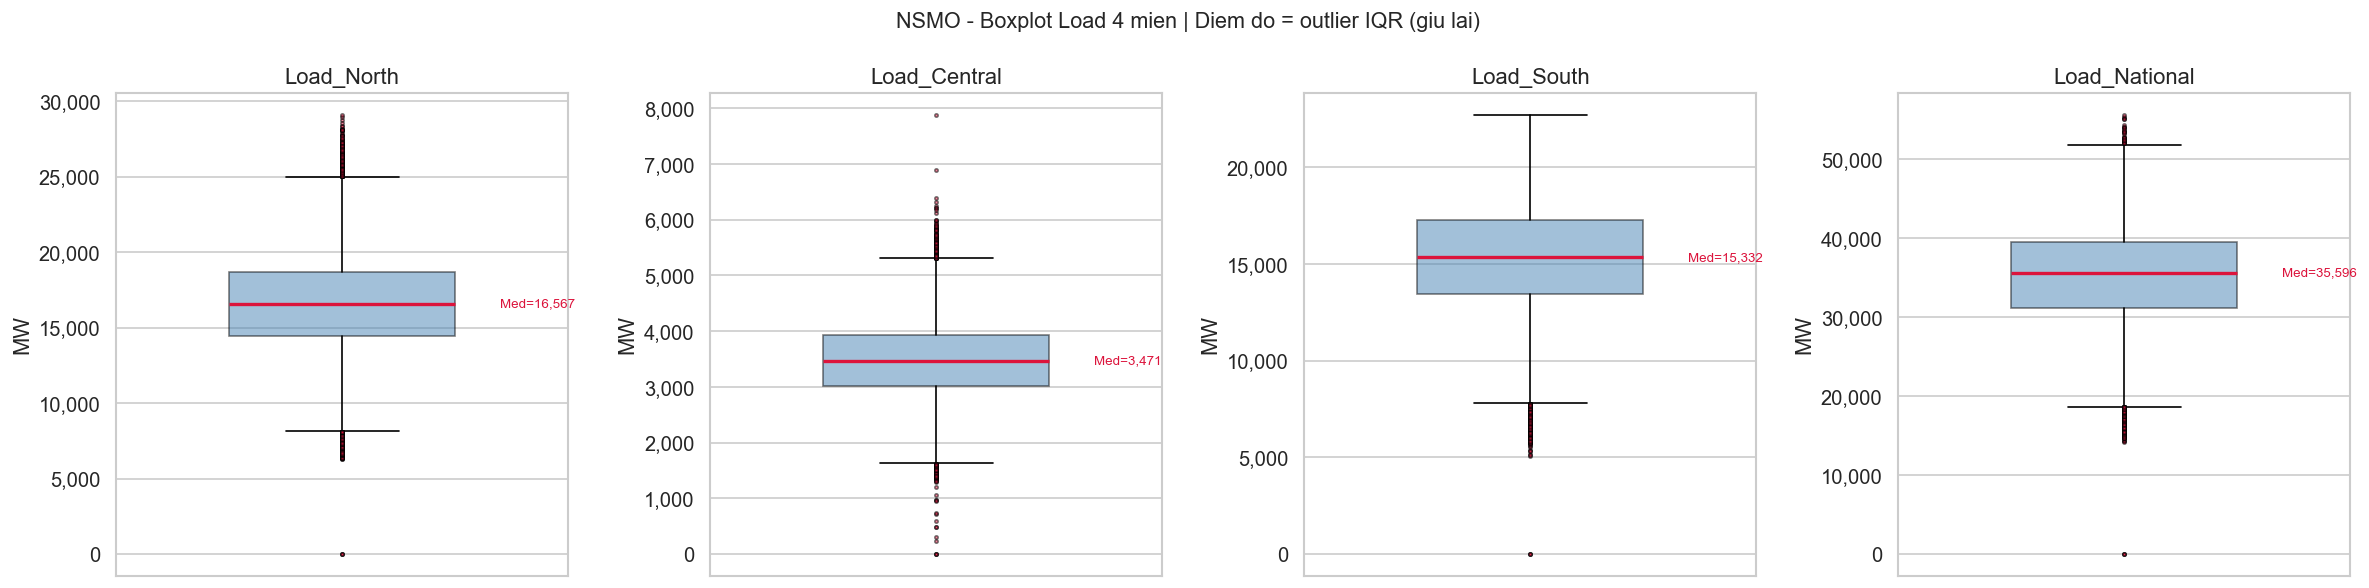

  -> Da luu: nsmo_boxplot_load.png


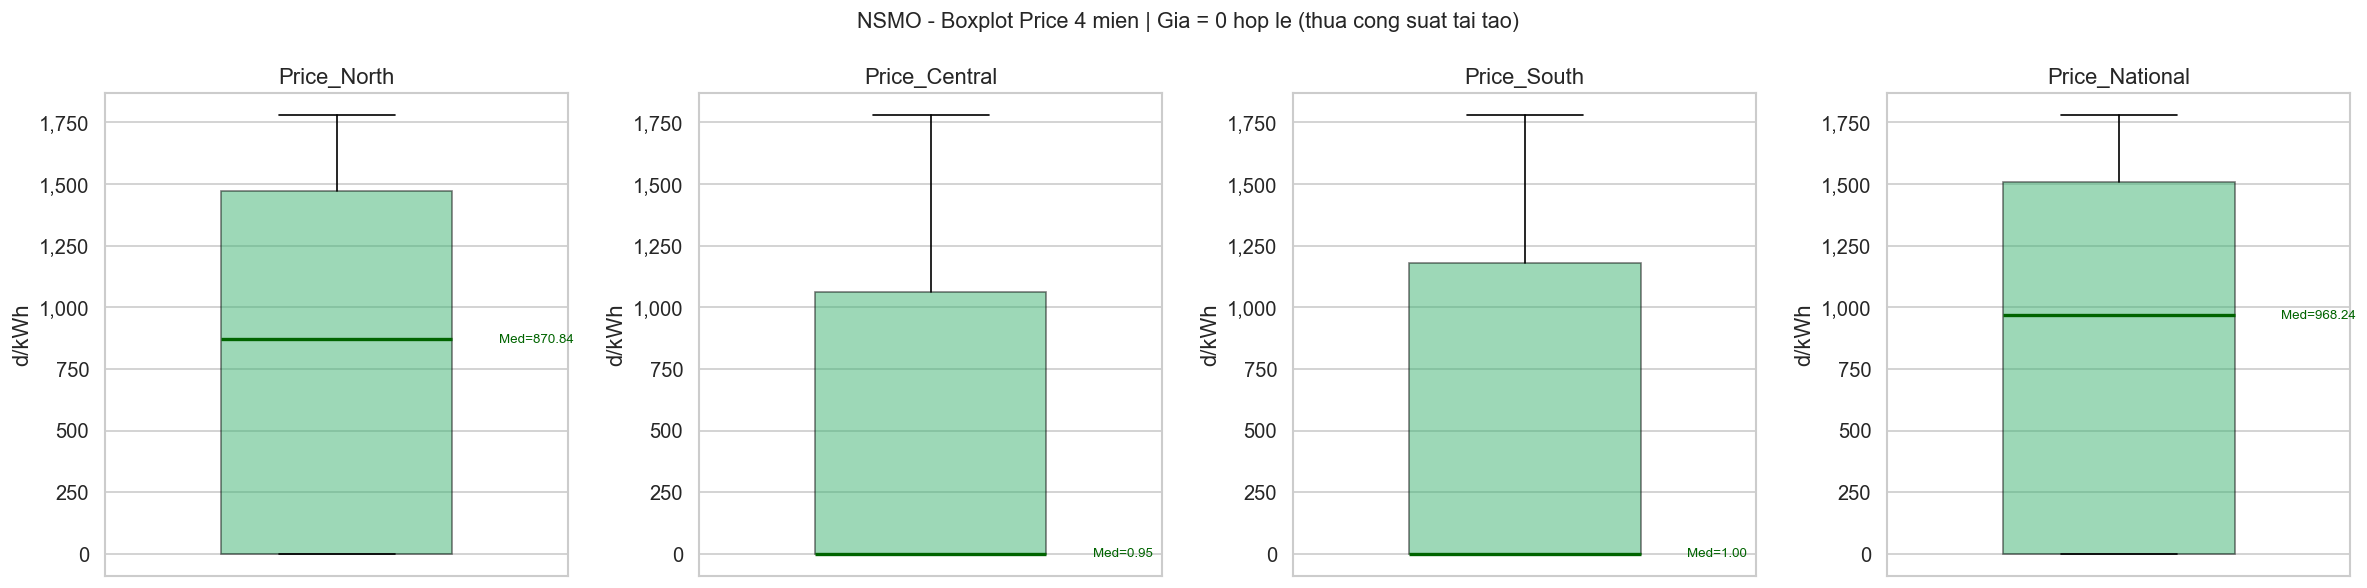

  -> Da luu: nsmo_boxplot_price.png


In [26]:
# 2.6 Visualize outlier NSMO

# 2.6a Scatter — phan bo outlier theo thoi gian
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, col in zip(axes, NSMO_LOAD_COLS):
    series = nsmo_clean[col]
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr

    outlier_mask = (series < lo) | (series > hi)
    ax.scatter(nsmo_clean.index[~outlier_mask], series[~outlier_mask],
               s=0.3, alpha=0.4, color='steelblue', label='Normal')
    ax.scatter(nsmo_clean.index[outlier_mask], series[outlier_mask],
               s=5, alpha=0.8, color='crimson',
               label=f'Outlier (n={outlier_mask.sum()})')
    ax.axhline(lo, color='orange', lw=1, ls='--', label='IQR fence')
    ax.axhline(hi, color='orange', lw=1, ls='--')
    ax.set_title(col)
    ax.set_xlabel('Index')
    ax.set_ylabel('MW')
    ax.legend(fontsize=8)

fig.suptitle('NSMO - Outlier Detection (IQR x 1.5) | Outlier duoc GIU LAI', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_EDA / 'nsmo_outlier_load.png', bbox_inches='tight', dpi=120)
plt.show()
print('  -> Da luu: nsmo_outlier_load.png')

# 2.6b Boxplot Load — phan phoi + outlier tong quan
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, col in zip(axes, NSMO_LOAD_COLS):
    ax.boxplot(
        nsmo_clean[col].dropna(), vert=True, patch_artist=True, widths=0.5,
        boxprops=dict(facecolor='steelblue', alpha=0.5),
        medianprops=dict(color='crimson', lw=2),
        flierprops=dict(marker='o', markersize=2, markerfacecolor='crimson', alpha=0.5)
    )
    med_val = nsmo_clean[col].median()
    ax.text(1.35, med_val, f'Med={med_val:,.0f}', va='center', fontsize=8, color='crimson')
    ax.set_title(col)
    ax.set_ylabel('MW')
    ax.set_xticks([])
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle('NSMO - Boxplot Load 4 mien | Diem do = outlier IQR (giu lai)', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_EDA / 'nsmo_boxplot_load.png', bbox_inches='tight', dpi=120)
plt.show()
print('  -> Da luu: nsmo_boxplot_load.png')

# 2.6c Boxplot Price
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, col in zip(axes, NSMO_PRICE_COLS):
    ax.boxplot(
        nsmo_clean[col].dropna(), vert=True, patch_artist=True, widths=0.5,
        boxprops=dict(facecolor='mediumseagreen', alpha=0.5),
        medianprops=dict(color='darkgreen', lw=2),
        flierprops=dict(marker='o', markersize=2, markerfacecolor='crimson', alpha=0.5)
    )
    med_val = nsmo_clean[col].median()
    # Dung :.2f vi Price co the rat nho (gan 0) — :.0f se hien sai thanh 1
    ax.text(1.35, med_val, f'Med={med_val:,.2f}', va='center', fontsize=8, color='darkgreen')
    ax.set_title(col)
    ax.set_ylabel('d/kWh')
    ax.set_xticks([])
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle('NSMO - Boxplot Price 4 mien | Gia = 0 hop le (thua cong suat tai tao)', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_EDA / 'nsmo_boxplot_price.png', bbox_inches='tight', dpi=120)
plt.show()
print('  -> Da luu: nsmo_boxplot_price.png')


In [27]:
# 2.7 Validate & luu output NSMO
print('  Validate NSMO clean:')
print(f'  So dong       : {len(nsmo_clean):,}')
print(f'  Timestamp min : {nsmo_clean["Timestamp"].min()}')
print(f'  Timestamp max : {nsmo_clean["Timestamp"].max()}')
print(f'  Missing total : {nsmo_clean.isnull().sum().sum()}')
print(f'  Duplicate TS  : {nsmo_clean["Timestamp"].duplicated().sum()}')
print(f'\n  Thong ke Load_North:')
print(nsmo_clean['Load_North'].describe().round(1).to_string())

assert nsmo_clean.isnull().sum().sum() == 0, '[ERROR] Con NaN sau cleaning'
assert nsmo_clean['Timestamp'].duplicated().sum() == 0, '[ERROR] Con duplicate TS'

save_clean(nsmo_clean, 'nsmo_v1_clean.csv')
print('[OK] NSMO cleaning hoan tat')


  Validate NSMO clean:
  So dong       : 52,608
  Timestamp min : 2023-03-11 00:30:00
  Timestamp max : 2026-03-11 00:00:00
  Missing total : 0
  Duplicate TS  : 0

  Thong ke Load_North:
count    52608.0
mean     16589.5
std       3144.6
min          0.0
25%      14444.0
50%      16566.6
75%      18663.0
max      29048.4
  -> Da luu: nsmo_v1_clean.csv -> 52,608 dong x 9 cot
[OK] NSMO cleaning hoan tat


## 3. Hàm làm sạch Weather (tái sử dụng cho 3 thành phố)

### Thiết kế
Ba thành phố Hà Nội / Đà Nẵng / TP.HCM có cùng schema → đóng gói thành **1 hàm** `clean_weather()`.  
Tránh copy-paste code, dễ debug nếu có thay đổi logic.

In [28]:
# Constants: cot drop, cot categorical, cot numeric giu lai
# Dinh nghia o day de tai su dung trong ca clean_weather() va EDA
WEATHER_DROP_COLS = [
    'name', 'stations', 'snow', 'snowdepth', 'severerisk',
    'dew', 'windgust', 'winddir', 'sealevelpressure',
    'visibility', 'solarenergy', 'preciptype'
]
# - snow, snowdepth  : luon = 0 tai Viet Nam
# - severerisk       : 81-85% missing
# - dew, sealevelpressure, windgust, winddir: tuong quan cao voi temp/windspeed
# - solarenergy      : tinh tu solarradiation (thong tin trung lap)
# - preciptype       : 80-88% missing, categorical kho impute
# - name, stations   : metadata crawl

WEATHER_CAT_COLS = ['conditions', 'icon']

WEATHER_KEEP_NUMERIC = [
    'temp', 'feelslike', 'humidity', 'precip', 'precipprob',
    'windspeed', 'cloudcover', 'solarradiation', 'uvindex'
]


def clean_weather(
    input_file: str,
    output_file: str,
    ts_col: str = 'datetime',
    city_label: str = ''
) -> pd.DataFrame:
    """Lam sach mot file weather theo pipeline chuan.

    Pipeline gom 6 buoc:
    1. Doc file va kiem tra ts_col ton tai.
    2. Drop cac cot khong co gia tri phan tich.
    3. Drop duplicate timestamp.
    4. Xu ly missing: linear interpolation (numeric), ffill/bfill (categorical).
    5. Detect outlier IQR va ghi log.
    6. Validate va luu output.

    Args:
        input_file: Ten file CSV dau vao (trong data/processed/).
        output_file: Ten file CSV dau ra.
        ts_col: Ten cot thoi gian trong file goc. Mac dinh 'datetime'.
        city_label: Nhan thanh pho, dung trong log va print.

    Returns:
        DataFrame da lam sach voi cot thoi gian la 'Timestamp'.
    """
    print(f'\nXu ly: {city_label} ({input_file})')

    # Buoc 1: Doc & kiem tra
    # Assertion dam bao fail som neu batch moi doi ten cot thoi gian
    df = load_processed(input_file, ts_col=ts_col)
    df = df.rename(columns={ts_col: 'Timestamp'})
    print(f'  Giai doan: {df["Timestamp"].min()} -> {df["Timestamp"].max()}')

    # Buoc 2: Drop cot khong can
    drop_actual = [c for c in WEATHER_DROP_COLS if c in df.columns]
    df = df.drop(columns=drop_actual)
    print(f'  Drop {len(drop_actual)} cot: {drop_actual}')
    print(f'  Con lai: {list(df.columns)}')

    # Buoc 3: Duplicate timestamp
    df = drop_duplicate_timestamps(df, ts_col='Timestamp', label=city_label)

    # Buoc 4: Xu ly missing
    print(f'\n  Missing truoc xu ly:')
    report_missing(df, label=city_label)

    # Numeric: linear interpolation chi no suy (khong ngoai suy).
    # limit_direction='forward' dam bao chi lay thong tin qua khu.
    # ffill/bfill xu ly edge case missing o dau/cuoi file.
    # Chon linear vi bien khi tuong (temp, humidity) thay doi lien tuc,
    # xap xi tuyen tinh hop ly cho gap ngan 1-3 gio.
    numeric_cols = list(df.select_dtypes(include='number').columns)
    df[numeric_cols] = (
        df[numeric_cols]
        .interpolate(method='linear', limit_direction='forward')
        .ffill()
        .bfill()
    )
    print(f'  Numeric ({len(numeric_cols)} cot): linear interpolation + edge ffill/bfill')

    # Categorical: forward fill.
    # Khong the no suy giua 2 nhan roi rac ('partly-cloudy' va 'clear').
    # Forward fill gia dinh trang thai duy tri den khi co quan sat moi.
    cat_actual = [c for c in WEATHER_CAT_COLS if c in df.columns]
    df[cat_actual] = df[cat_actual].ffill().bfill()
    print(f'  Categorical {cat_actual}: forward fill + edge bfill')
    print(f'  Missing sau xu ly: {df.isnull().sum().sum()}')

    # Buoc 5: Detect outlier IQR
    outlier_check_cols = [c for c in WEATHER_KEEP_NUMERIC if c in df.columns]
    detect_outliers_iqr(
        df, cols=outlier_check_cols,
        ts_col='Timestamp',
        label=city_label.lower().replace(' ', '_')
    )

    # Buoc 6: Validate & luu
    print(f'  So dong       : {len(df):,}')
    print(f'  Missing total : {df.isnull().sum().sum()}')
    assert df.isnull().sum().sum() == 0, f'[ERROR] Con NaN sau cleaning {city_label}'
    assert df['Timestamp'].duplicated().sum() == 0, '[ERROR] Con duplicate TS'

    save_clean(df, output_file)
    return df


print('[OK] Ham clean_weather() da san sang')


[OK] Ham clean_weather() da san sang


## 4. Làm sạch Hà Nội (Miền Bắc)

In [29]:
# Phan 4 - Lam sach Ha Noi (Mien Bac)
hanoi_clean = clean_weather(
    input_file='hanoi_raw_merged.csv',
    output_file='hanoi_v1_clean.csv',
    ts_col='datetime',
    city_label='Hanoi'
)
print('[OK] Ha Noi cleaning hoan tat')



Xu ly: Hanoi (hanoi_raw_merged.csv)
  [OK] Doc: hanoi_raw_merged.csv -> 26,304 dong x 24 cot
  Giai doan: 2023-03-11 00:00:00 -> 2026-03-10 23:00:00
  Drop 12 cot: ['name', 'stations', 'snow', 'snowdepth', 'severerisk', 'dew', 'windgust', 'winddir', 'sealevelpressure', 'visibility', 'solarenergy', 'preciptype']
  Con lai: ['Timestamp', 'temp', 'feelslike', 'humidity', 'precip', 'precipprob', 'windspeed', 'cloudcover', 'solarradiation', 'uvindex', 'conditions', 'icon']
  [OK] [Hanoi] Khong co duplicate timestamp

  Missing truoc xu ly:
  [OK] [Hanoi] Khong co missing value
  Numeric (9 cot): linear interpolation + edge ffill/bfill
  Categorical ['conditions', 'icon']: forward fill + edge bfill
  Missing sau xu ly: 0
  Outlier summary (IQR x 1.5) [hanoi]:
        column  lower_fence  upper_fence  n_outliers  pct_outliers
          temp      9.00000     41.00000           6         0.023
     feelslike      0.75000     54.75000           0         0.000
      humidity     36.72625    123

## 5. Làm sạch Đà Nẵng (Miền Trung)

In [30]:
# Phan 5 - Lam sach Da Nang (Mien Trung)
danang_clean = clean_weather(
    input_file='danang_raw_merged.csv',
    output_file='danang_v1_clean.csv',
    ts_col='datetime',
    city_label='DaNang'
)
print('[OK] Da Nang cleaning hoan tat')



Xu ly: DaNang (danang_raw_merged.csv)
  [OK] Doc: danang_raw_merged.csv -> 26,304 dong x 24 cot
  Giai doan: 2023-03-11 00:00:00 -> 2026-03-10 23:00:00
  Drop 12 cot: ['name', 'stations', 'snow', 'snowdepth', 'severerisk', 'dew', 'windgust', 'winddir', 'sealevelpressure', 'visibility', 'solarenergy', 'preciptype']
  Con lai: ['Timestamp', 'temp', 'feelslike', 'humidity', 'precip', 'precipprob', 'windspeed', 'cloudcover', 'solarradiation', 'uvindex', 'conditions', 'icon']
  [OK] [DaNang] Khong co duplicate timestamp

  Missing truoc xu ly:
  [OK] [DaNang] Khong co missing value
  Numeric (9 cot): linear interpolation + edge ffill/bfill
  Categorical ['conditions', 'icon']: forward fill + edge bfill
  Missing sau xu ly: 0
  Outlier summary (IQR x 1.5) [danang]:
        column  lower_fence  upper_fence  n_outliers  pct_outliers
          temp       16.200       37.000          82         0.312
     feelslike        8.100       50.500           0         0.000
      humidity       43.075 

## 6. Làm sạch TP.HCM (Miền Nam)

In [31]:
# Phan 6 - Lam sach TP.HCM (Mien Nam)
hcm_clean = clean_weather(
    input_file='hcm_raw_merged.csv',
    output_file='hcm_v1_clean.csv',
    ts_col='datetime',
    city_label='TPHCM'
)
print('[OK] TP.HCM cleaning hoan tat')



Xu ly: TPHCM (hcm_raw_merged.csv)
  [OK] Doc: hcm_raw_merged.csv -> 26,304 dong x 24 cot
  Giai doan: 2023-03-11 00:00:00 -> 2026-03-10 23:00:00
  Drop 12 cot: ['name', 'stations', 'snow', 'snowdepth', 'severerisk', 'dew', 'windgust', 'winddir', 'sealevelpressure', 'visibility', 'solarenergy', 'preciptype']
  Con lai: ['Timestamp', 'temp', 'feelslike', 'humidity', 'precip', 'precipprob', 'windspeed', 'cloudcover', 'solarradiation', 'uvindex', 'conditions', 'icon']
  [OK] [TPHCM] Khong co duplicate timestamp

  Missing truoc xu ly:
  [OK] [TPHCM] Khong co missing value
  Numeric (9 cot): linear interpolation + edge ffill/bfill
  Categorical ['conditions', 'icon']: forward fill + edge bfill
  Missing sau xu ly: 0
  Outlier summary (IQR x 1.5) [tphcm]:
        column  lower_fence  upper_fence  n_outliers  pct_outliers
          temp     18.75000     38.35000           3         0.011
     feelslike     10.20000     52.60000           0         0.000
      humidity     31.56375    124.213

## 7. So sánh trước / sau xử lý (EDA định lượng)

Theo yêu cầu của giảng viên: **EDA phải có số liệu định lượng**, không nói chung chung.

In [32]:
# 7.1 NSMO: thong ke mo ta truoc vs sau — du 8 cot Load + Price
# Giang vien yeu cau so lieu dinh luong; mo rong ra toan bo cot thay vi chi Load_North
nsmo_before = load_processed('nsmo_raw_merged.csv', ts_col='Timestamp')

for col in NSMO_LOAD_COLS + NSMO_PRICE_COLS:
    unit = 'MW' if col.startswith('Load') else 'd/kWh'
    compare = pd.DataFrame({
        'Truoc (raw)': nsmo_before[col].describe(),
        'Sau (clean)': nsmo_clean[col].describe()
    }).round(2)
    print(f'\n  [{col}] ({unit})')
    print(compare.to_string())

print('\n  -> Neu median Truoc ~ Sau: xac nhan fillna median khong lam lech phan phoi')


  [OK] Doc: nsmo_raw_merged.csv -> 52,608 dong x 9 cot

  [Load_North] (MW)
       Truoc (raw)  Sau (clean)
count     52608.00     52608.00
mean      16589.50     16589.50
std        3144.56      3144.56
min           0.00         0.00
25%       14444.00     14444.00
50%       16566.55     16566.55
75%       18662.98     18662.98
max       29048.42     29048.42

  [Load_Central] (MW)
       Truoc (raw)  Sau (clean)
count     52608.00     52608.00
mean       3473.32      3473.32
std         653.27       653.27
min           0.00         0.00
25%        3009.75      3009.75
50%        3471.37      3471.37
75%        3929.39      3929.39
max        7871.79      7871.79

  [Load_South] (MW)
       Truoc (raw)  Sau (clean)
count     52608.00     52608.00
mean      15276.50     15276.50
std        2577.86      2577.86
min           0.00         0.00
25%       13457.50     13457.50
50%       15331.96     15331.96
75%       17242.50     17242.50
max       22670.70     22670.70

  [Load_Nationa

In [33]:
# 7.2 Weather: so sanh missing truoc vs sau (3 thanh pho) va luu summary
CITY_CONFIG = [
    ('hanoi_raw_merged.csv',  hanoi_clean,  'Ha Noi'),
    ('danang_raw_merged.csv', danang_clean, 'Da Nang'),
    ('hcm_raw_merged.csv',    hcm_clean,    'TP.HCM'),
]

cleaning_summary = {}

for raw_file, clean_df, city_name in CITY_CONFIG:
    print(f'\n  [{city_name}]')
    before_df = load_processed(raw_file, ts_col='datetime')

    kept_cols = [
        c for c in before_df.columns
        if c not in WEATHER_DROP_COLS and c != 'datetime'
    ]

    miss_before = before_df[kept_cols].isnull().sum().rename('missing_before')
    miss_after = clean_df.reindex(columns=kept_cols).isnull().sum().rename('missing_after')

    miss_compare = pd.concat([miss_before, miss_after], axis=1)
    miss_compare['pct_before'] = (
        miss_compare['missing_before'] / len(before_df) * 100
    ).round(2)
    miss_compare['pct_after'] = (
        miss_compare['missing_after'] / len(clean_df) * 100
    ).round(2)

    has_miss = miss_compare[miss_compare['missing_before'] > 0]
    if has_miss.empty:
        print('  [OK] Khong co missing trong cac cot giu lai')
    else:
        print(has_miss.to_string())

    total_before = int(before_df[kept_cols].isnull().sum().sum())
    total_after = int(clean_df.reindex(columns=kept_cols).isnull().sum().sum())
    cleaning_summary[city_name] = {
        'rows_raw': len(before_df),
        'rows_clean': len(clean_df),
        'missing_before': total_before,
        'missing_after': total_after,
        'cols_dropped': [c for c in WEATHER_DROP_COLS if c in before_df.columns],
    }

cleaning_summary['NSMO'] = {
    'rows_raw': len(nsmo_before),
    'rows_clean': len(nsmo_clean),
    'missing_before': int(
        nsmo_before[NSMO_LOAD_COLS + NSMO_PRICE_COLS].isnull().sum().sum()
    ),
    'missing_after': int(
        nsmo_clean[NSMO_LOAD_COLS + NSMO_PRICE_COLS].isnull().sum().sum()
    ),
    'outlier_strategy': 'IQR detect, ghi log, KHONG xoa',
    'load_impute': 'median',
    'price_impute': 'forward fill + bfill edge',
}

summary_path = PROCESSED_DIR / 'cleaning_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(cleaning_summary, f, indent=2, ensure_ascii=False)
print(f'\n  -> Da luu: cleaning_summary.json')
print('  (Dung file nay de dien so lieu dinh luong vao bao cao)')



  [Ha Noi]
  [OK] Doc: hanoi_raw_merged.csv -> 26,304 dong x 24 cot
  [OK] Khong co missing trong cac cot giu lai

  [Da Nang]
  [OK] Doc: danang_raw_merged.csv -> 26,304 dong x 24 cot
  [OK] Khong co missing trong cac cot giu lai

  [TP.HCM]
  [OK] Doc: hcm_raw_merged.csv -> 26,304 dong x 24 cot
  [OK] Khong co missing trong cac cot giu lai

  -> Da luu: cleaning_summary.json
  (Dung file nay de dien so lieu dinh luong vao bao cao)


  [INFO] NSMO Load: 0 missing -> fillna khong kich hoat
         -> Histogram Truoc va Sau chong khit: pipeline giu nguyen phan phoi


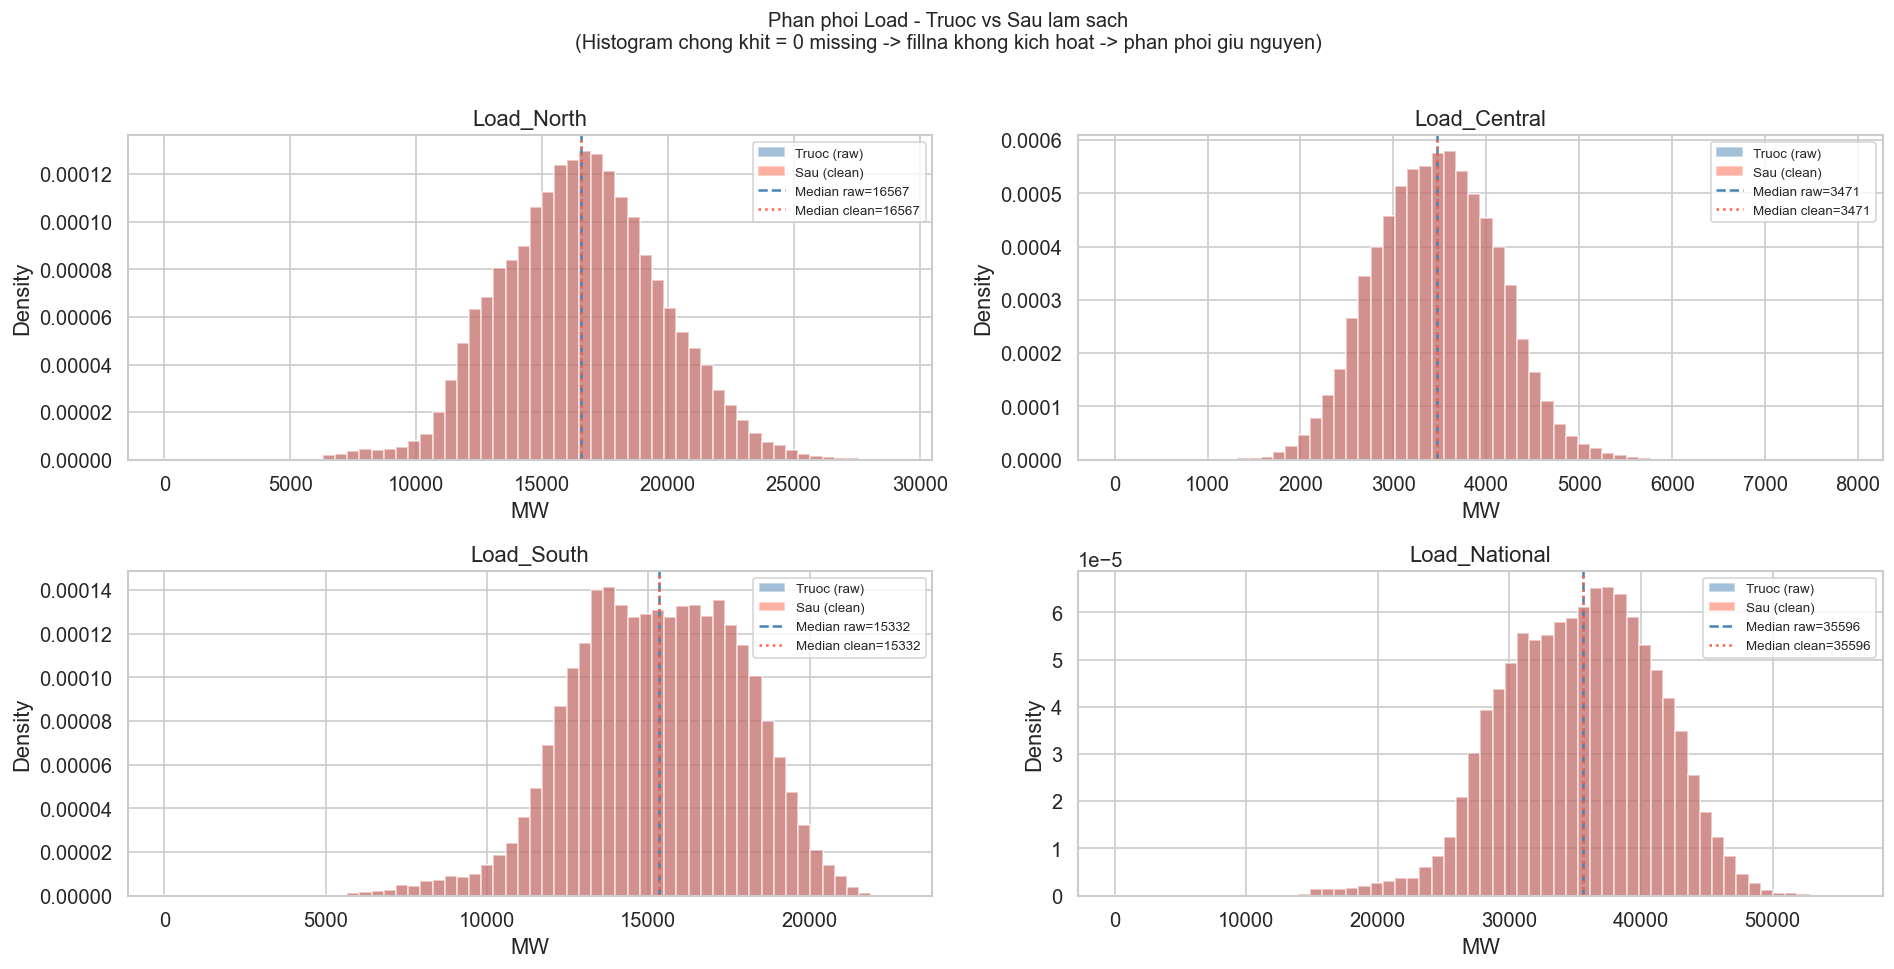

  -> Da luu: nsmo_load_dist_before_after.png


In [34]:
# 7.3 Phan phoi Load truoc vs sau lam sach
# Neu 0 missing, 2 histogram chong khit hoan toan — day la ket qua dung:
# pipeline khong lam lech phan phoi goc
n_missing_total = sum(nsmo_before[col].isna().sum() for col in NSMO_LOAD_COLS)
if n_missing_total == 0:
    print('  [INFO] NSMO Load: 0 missing -> fillna khong kich hoat')
    print('         -> Histogram Truoc va Sau chong khit: pipeline giu nguyen phan phoi')

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, NSMO_LOAD_COLS):
    ax.hist(nsmo_before[col].dropna(), bins=60, alpha=0.5,
            color='steelblue', label='Truoc (raw)', density=True)
    ax.hist(nsmo_clean[col].dropna(), bins=60, alpha=0.5,
            color='tomato', label='Sau (clean)', density=True)
    ax.axvline(nsmo_before[col].median(), color='steelblue', lw=1.5, ls='--',
               label='Median raw=' + str(round(nsmo_before[col].median())))
    ax.axvline(nsmo_clean[col].median(), color='tomato', lw=1.5, ls=':',
               label='Median clean=' + str(round(nsmo_clean[col].median())))
    ax.set_title(col)
    ax.set_xlabel('MW')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

fig.suptitle(
    'Phan phoi Load - Truoc vs Sau lam sach\n'
    '(Histogram chong khit = 0 missing -> fillna khong kich hoat -> phan phoi giu nguyen)',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(REPORTS_EDA / 'nsmo_load_dist_before_after.png', bbox_inches='tight', dpi=120)
plt.show()
print('  -> Da luu: nsmo_load_dist_before_after.png')


  [OK] Doc: hanoi_raw_merged.csv -> 26,304 dong x 24 cot


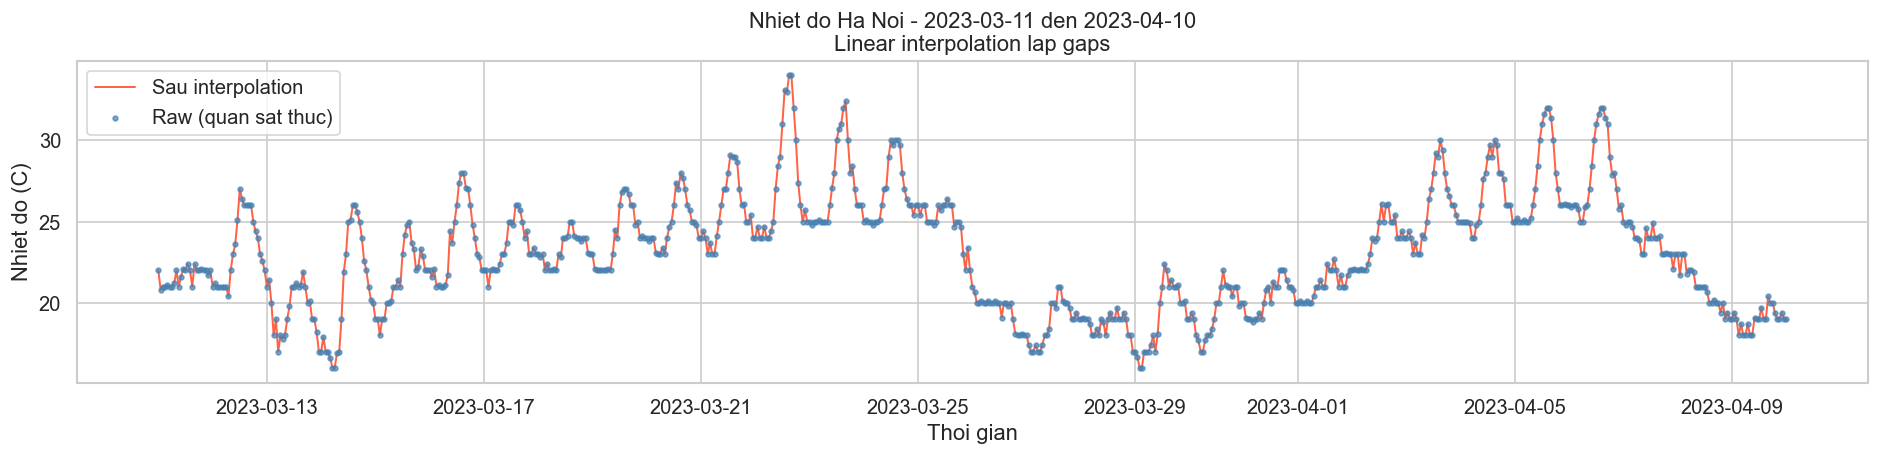

  -> Da luu: hanoi_temp_interpolation.png


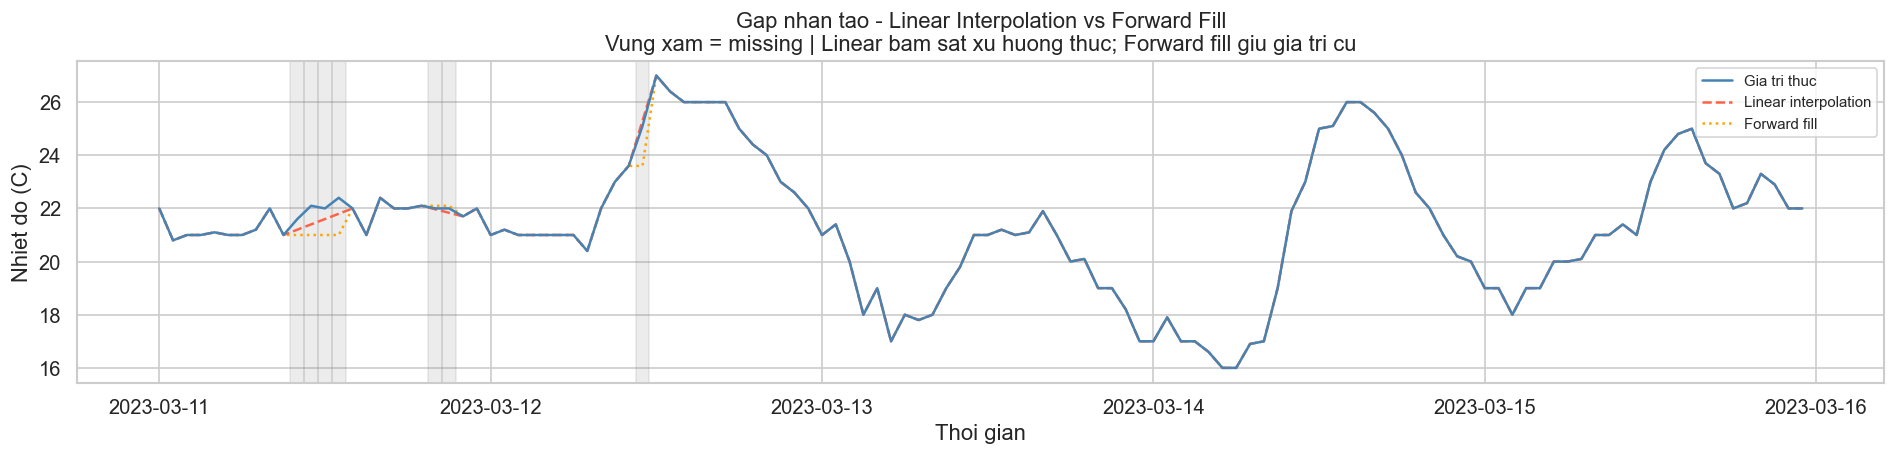

  -> Da luu: hanoi_temp_gap_demo.png
  -> Linear bam sat gia tri thuc trong vung gap
  -> Forward fill giu nguyen gia tri cu, lech khi nhiet do dang thay doi


In [35]:
# 7.4 Nhiet do Ha Noi truoc/sau interpolation

# Load lai hanoi_raw vi bien hanoi_before khong con sau khi cell 7.2
# duoc refactor thanh vong lap CITY_CONFIG
hanoi_raw_viz = load_processed('hanoi_raw_merged.csv', ts_col='datetime')

sample_start = '2023-03-11'
sample_end   = '2023-04-10'

hanoi_b_sample = hanoi_raw_viz[
    (hanoi_raw_viz['datetime'] >= sample_start) &
    (hanoi_raw_viz['datetime'] <= sample_end)
].copy()

hanoi_c_sample = hanoi_clean[
    (hanoi_clean['Timestamp'] >= sample_start) &
    (hanoi_clean['Timestamp'] <= sample_end)
].copy()

# 7.4a Line plot: toan bo 30 ngay
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(hanoi_c_sample['Timestamp'], hanoi_c_sample['temp'],
        color='tomato', lw=1.2, label='Sau interpolation', zorder=2)
ax.scatter(hanoi_b_sample['datetime'], hanoi_b_sample['temp'],
           s=8, color='steelblue', alpha=0.7, zorder=3,
           label='Raw (quan sat thuc)')
ax.set_title(
    'Nhiet do Ha Noi - ' + sample_start + ' den ' + sample_end + '\n'
    'Linear interpolation lap gaps'
)
ax.set_xlabel('Thoi gian')
ax.set_ylabel('Nhiet do (C)')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_EDA / 'hanoi_temp_interpolation.png', bbox_inches='tight', dpi=120)
plt.show()
print('  -> Da luu: hanoi_temp_interpolation.png')

# 7.4b Gap nhan tao — minh hoa hieu qua interpolation so voi forward fill
# Data thuc khong co missing nen tao gap nhan tao de thay ro su khac biet.
demo_df = hanoi_b_sample.head(5 * 24).copy().rename(columns={'datetime': 'Timestamp'})
gap_indices = list(range(10, 14)) + [20, 21, 35]
demo_with_gap = demo_df.copy()
demo_with_gap.loc[demo_with_gap.index[gap_indices], 'temp'] = float('nan')

demo_linear = demo_with_gap['temp'].interpolate(method='linear').values
demo_ffill  = demo_with_gap['temp'].ffill().values
demo_true   = demo_df['temp'].values

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(demo_df['Timestamp'], demo_true,
        color='steelblue', lw=1.5, label='Gia tri thuc', zorder=4)
ax.plot(demo_df['Timestamp'], demo_linear,
        color='tomato', lw=1.5, ls='--', label='Linear interpolation', zorder=3)
ax.plot(demo_df['Timestamp'], demo_ffill,
        color='orange', lw=1.5, ls=':', label='Forward fill', zorder=2)

for idx in gap_indices:
    ax.axvspan(
        demo_df['Timestamp'].iloc[idx] - pd.Timedelta('30min'),
        demo_df['Timestamp'].iloc[idx] + pd.Timedelta('30min'),
        alpha=0.15, color='gray'
    )

ax.set_title(
    'Gap nhan tao - Linear Interpolation vs Forward Fill\n'
    'Vung xam = missing | Linear bam sat xu huong thuc; Forward fill giu gia tri cu'
)
ax.set_xlabel('Thoi gian')
ax.set_ylabel('Nhiet do (C)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(REPORTS_EDA / 'hanoi_temp_gap_demo.png', bbox_inches='tight', dpi=120)
plt.show()
print('  -> Da luu: hanoi_temp_gap_demo.png')
print('  -> Linear bam sat gia tri thuc trong vung gap')
print('  -> Forward fill giu nguyen gia tri cu, lech khi nhiet do dang thay doi')


## 8. Tổng kết Notebook 04

In [36]:
# Tong ket Notebook 04
outputs = [
    ('nsmo_v1_clean.csv',   nsmo_clean),
    ('hanoi_v1_clean.csv',  hanoi_clean),
    ('danang_v1_clean.csv', danang_clean),
    ('hcm_v1_clean.csv',    hcm_clean),
]

summary_rows = []
for fname, df in outputs:
    summary_rows.append({
        'File'   : fname,
        'Rows'   : f'{len(df):,}',
        'Cols'   : df.shape[1],
        'Missing': df.isnull().sum().sum(),
        'TS min' : str(df['Timestamp'].min())[:16],
        'TS max' : str(df['Timestamp'].max())[:16],
    })

summary_df = pd.DataFrame(summary_rows)
print('Output files:')
print(summary_df.to_string(index=False))
print()
print('[OK] Tat ca output da luu vao data/processed/')
print('[OK] Outlier logs da luu vao reports/cleaning_logs/')
print('[OK] Bieu do da luu vao reports/eda_before/')
print('[OK] cleaning_summary.json da luu vao data/processed/')
print()
print('Buoc tiep theo: Notebook 05 - Integration')
print('  Input : *_v1_clean.csv (NSMO=30min, Weather=1h)')
print('  Output: unified_v1_merged.csv (30min, tat ca features)')


Output files:
               File   Rows  Cols  Missing           TS min           TS max
  nsmo_v1_clean.csv 52,608     9        0 2023-03-11 00:30 2026-03-11 00:00
 hanoi_v1_clean.csv 26,304    12        0 2023-03-11 00:00 2026-03-10 23:00
danang_v1_clean.csv 26,304    12        0 2023-03-11 00:00 2026-03-10 23:00
   hcm_v1_clean.csv 26,304    12        0 2023-03-11 00:00 2026-03-10 23:00

[OK] Tat ca output da luu vao data/processed/
[OK] Outlier logs da luu vao reports/cleaning_logs/
[OK] Bieu do da luu vao reports/eda_before/
[OK] cleaning_summary.json da luu vao data/processed/

Buoc tiep theo: Notebook 05 - Integration
  Input : *_v1_clean.csv (NSMO=30min, Weather=1h)
  Output: unified_v1_merged.csv (30min, tat ca features)
